# Problem 1
***

##### NOTE! I used chatGPT and lecture notes to compute some of the code.


In [1]:
# This imports the package we specify. It opens up for functions we cannot use if not imported.
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from itertools import islice

In [2]:
# Define the ticker. For each of the tickers I add the corresponding names
tickers = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'BP': 'BP plc',
    'JNJ': 'Johnson & Johnson',
    'NVS': 'Novartis AG',
    'KO': 'The Coca Cola Company',
    'UL': 'Unilever Plc',
    'JPM': 'JP Morgan Chase & Co',
    'BCS': 'Barclays Plc',
    'SONY': 'Sony',
    '^GSPC': 'S&P Index 500'
}

# Defining the start and end date for the data.
start_date = '2013-01-01'
end_date = '2023-05-31'

# Download historical data. Using a for loop that goes through all tickers, with start as start_date and end as end_date given. The ['Adj Close'] only gives the 
#Adjusted close column with the correct index. 
data = {}
for ticker, name in tickers.items():
    data[name] = yf.download(ticker, start=start_date, end=end_date)['Adj Close']



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Missing Data

In [3]:
# This line of code checks for missing values in the DataFrame.
# It does this by calling isnull(), which returns a DataFrame where each cell is either True or False
# depending on whether that cell in the original DataFrame is a missing value. The sum() method is then called on
# this result to add up the True values, giving us the total number of missing values in the DataFrame. The f in the print() makes python plot
# the values instead of the variables inside {} brackets. 

# The for loop in each of the chunks goes through each name in the ticker I made.

for name, df in data.items():
    print(f"Missing values for {name}: {df.isnull().sum()}")

Missing values for Apple: 0
Missing values for Microsoft: 0
Missing values for BP plc: 0
Missing values for Johnson & Johnson: 0
Missing values for Novartis AG: 0
Missing values for The Coca Cola Company: 0
Missing values for Unilever Plc: 0
Missing values for JP Morgan Chase & Co: 0
Missing values for Barclays Plc: 0
Missing values for Sony: 0
Missing values for S&P Index 500: 0


### Duplicates

In [4]:
# This line of code checks for duplicate rows in the DataFrame.
# We expect each date to have a unique row of stock price data. If there are duplicates, it might indicate a problem
# with the data collection process.
for name, df in data.items():
    print(f"Duplicates for {name}: {df.duplicated().sum()}")

Duplicates for Apple: 39
Duplicates for Microsoft: 105
Duplicates for BP plc: 211
Duplicates for Johnson & Johnson: 75
Duplicates for Novartis AG: 249
Duplicates for The Coca Cola Company: 236
Duplicates for Unilever Plc: 210
Duplicates for JP Morgan Chase & Co: 90
Duplicates for Barclays Plc: 579
Duplicates for Sony: 428
Duplicates for S&P Index 500: 13


### Outliers

In [5]:
# This part of the code calculates the Z-score for each data point in the column,
# and checks if it is greater than 3 or less than -3. The absolute value of the Z-score is taken, so this
# works for both ends of the distribution. The result is a DataFrame where each cell is either True or False,
# depending on whether that cell in the original DataFrame is an outlier. The sum() is then called on
# this result to add up the True values, giving us the total number of outliers. This gives us a 

for name, df in data.items():
    z_scores = (df - df.mean())/df.std()
    print(f"Number of outliers for {name}: {(z_scores > 3).sum()}")

Number of outliers for Apple: 0
Number of outliers for Microsoft: 0
Number of outliers for BP plc: 0
Number of outliers for Johnson & Johnson: 0
Number of outliers for Novartis AG: 0
Number of outliers for The Coca Cola Company: 0
Number of outliers for Unilever Plc: 0
Number of outliers for JP Morgan Chase & Co: 0
Number of outliers for Barclays Plc: 0
Number of outliers for Sony: 0
Number of outliers for S&P Index 500: 0


### Descriptive statistics

In [6]:
for name, df in data.items():
    # Use the describe() to generate descriptive statistics
    print(f"Descriptive statistics for {name}:")
    print(df.describe())

# This "\n" creates air between the chunks. To see all the data, you can click the "scrollable element" at the bottom of the output.
    print("\n")

Descriptive statistics for Apple:
count    2620.000000
mean       64.168071
std        51.610934
min        12.029553
25%        24.965215
50%        40.813364
75%       115.439369
max       180.434311
Name: Adj Close, dtype: float64


Descriptive statistics for Microsoft:
count    2620.000000
mean      122.838040
std        93.823473
min        21.716198
25%        41.623544
50%        87.673771
75%       209.007050
max       338.335907
Name: Adj Close, dtype: float64


Descriptive statistics for BP plc:
count    2620.000000
mean       26.570124
std         5.068042
min        13.037460
25%        23.096312
50%        25.687389
75%        30.365757
max        40.507629
Name: Adj Close, dtype: float64


Descriptive statistics for Johnson & Johnson:
count    2620.000000
mean      114.499815
std        33.289532
min        53.097187
25%        82.609425
50%       114.141357
75%       138.624641
max       179.752579
Name: Adj Close, dtype: float64


Descriptive statistics for Novartis AG:

### Data quality

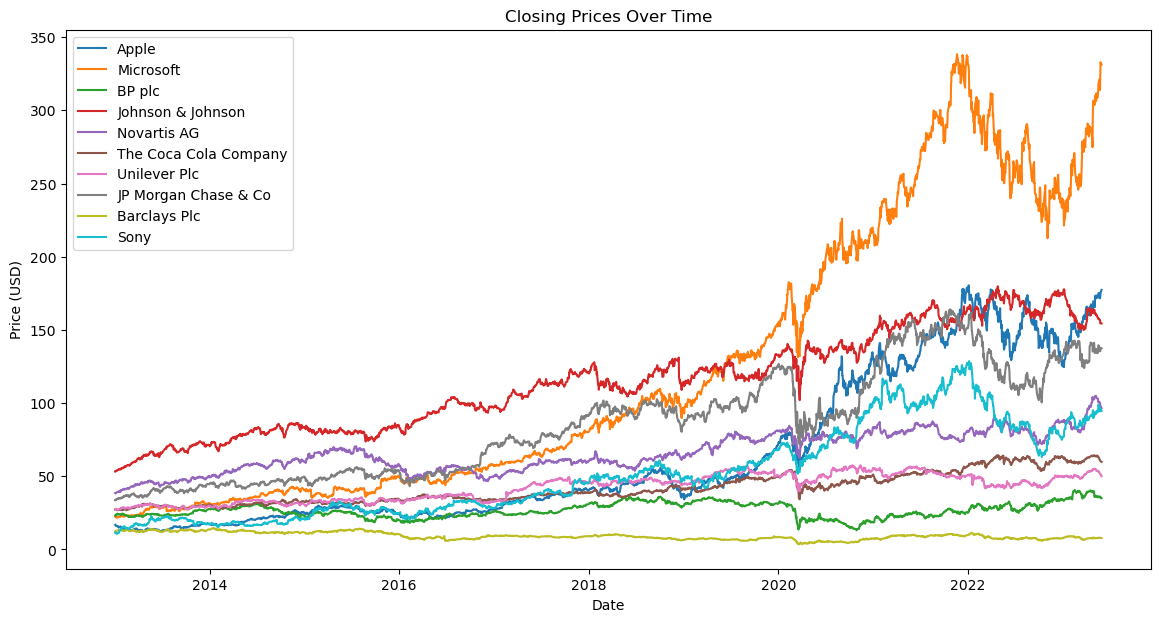

In [7]:
# Create a new figure
plt.figure(figsize=(14,7))

# Because the S&P Index is so much larger than the rest in scale, I just print the first 10 (All except this index). 
# This function gets the tickers for the first 10 in data. 
first_10 = islice(data.items(), 10)

# Loop over each DataFrame in the data dictionary
for name, df in first_10:
    # Plot the 'Close' column
    plt.plot(df, label=name)

# Add a title
plt.title('Closing Prices Over Time')

# Add an x-label
plt.xlabel('Date')

# Add a y-label
plt.ylabel('Price (USD)')

# Add a legend
plt.legend()

# Display the plot
plt.show()

##### From the outputs created we can get good insight in the quality of the data. Firstly, we see that there are no missing values in the data. This is a good sign, and we don't need to look into what causes the missing data here. From the duplicates we can see that there are a lot of duplicate elements. The reason for this is not clear. Some of them only have two decimals, and could be the reason for the duplicates, but some also has 6, which does not make sense to have that much duplicates then. The plots however, look really nice and does not look distorted or anything like this. This makes me believe it is just random reason they are duplicated. As well as this there are no outliers in the data, which is good. I could have checked for log return outliers, but I don't really think that is relevant.